In [1]:
# !pip3 install dendropy
# !pip3 install pandas
# !pip3 install numpy
# !pip3 install matplotlib
# !pip3 install seaborn
# !pip3 install scipy
# !pip3 install tqdm
# !pip3 install torch torchvision

In [2]:
import dendropy
import pandas as pd

from dendropy import Taxon
from scipy.special import logit, expit
from tqdm import tqdm
from aux_fns import *

%load_ext autoreload
%autoreload 2

In [3]:
V = 1000
AD = pd.read_csv("../process_dlp_data/AD_true.csv", index_col=0).sample(n=V)
DP = pd.read_csv("../process_dlp_data/DP_true.csv", index_col=0).loc[AD.index]

N = AD.shape[1]
print(N, V)
assert AD.shape == (V, N)
assert AD.shape == DP.shape

239 1000


In [4]:
edges_true = pd.read_csv("../process_dlp_data/edges.csv", index_col=0)
edges_true.cell_id = edges_true.cell_id.astype(str)
edges_true.ancestor = edges_true.ancestor.astype(str)
leaves = set(edges_true.cell_id.astype(str).tolist()) - set(edges_true.ancestor.tolist())

N = len(leaves)

In [5]:
edges_leaves = edges_true.loc[edges_true["cell_id"].isin(leaves)]
assert edges_leaves.shape[0] == N
assignments_tmp = {edges_leaves.iloc[i].cell_id:edges_leaves.iloc[i].mutant for i in range(N)}

## Tree

In [6]:
if "root" not in edges_true["cell_id"].values:
    edges_true = pd.concat([pd.DataFrame({"cell_id": ["root"], "ancestor": [None], "birth_time": [0]}), edges_true])
    
taxa = dendropy.TaxonNamespace(leaves)
nodes = {"root": dendropy.Node(label="root")}
tree = dendropy.Tree(seed_node=nodes["root"], taxon_namespace=taxa)

def get_node(label):
    if label not in nodes:
        nodes[label] = dendropy.Node(label=label)
    if label in leaves:
        nodes[label].taxon = taxa.get_taxon(label)
    return nodes[label]

for _, row in edges_true.iterrows():
    if row["ancestor"] is None:
        continue
    parent = get_node(row["ancestor"])
    child = get_node(row["cell_id"])
    parent.add_child(child)
    child.edge.length = float(row["weight"])

tree.seed_node = nodes["root"]

## Dendrogram

In [7]:
cell_ids, linkage_matrix = assign_clones_from_tree(tree)  # dict: {cell_id:clone_id, ...}

assignments = {cell_id:assignments_tmp[str(cell_id)] for cell_id in cell_ids}
cell_ids = list(assignments.keys())
clone_ids = list(assignments.values())

In [8]:
unique_groups = set(clone_ids)
color_list = ["#5F9EA0","#FF4500","#DAA520","#7B68EE"]
color_map = {group: color_list[i % len(color_list)] for i, group in enumerate(unique_groups)}
label_colors = [color_map[group] for group in clone_ids]

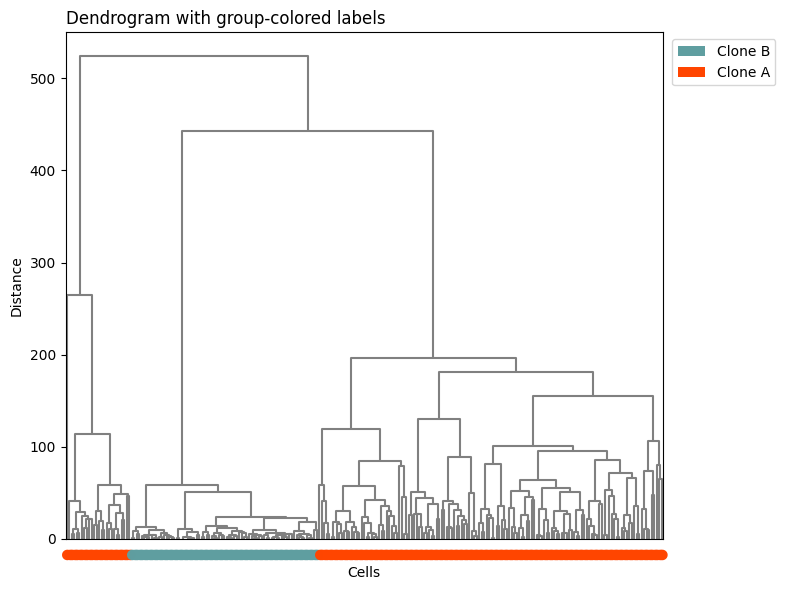

In [9]:
plot_dendogram(linkage_matrix, cell_ids, clone_ids, color_map)

In [10]:
edges = tree_to_edge_list(tree)
kernel = compute_ou_kernel(edges, list(assignments.keys()), lambd=.05, sigma_squared=1.0)
# pd.DataFrame(kernel).to_csv(save_path + "kernel.csv", index=False)

assert kernel.shape[0] == kernel.shape[1]
assert kernel.shape[0] == N

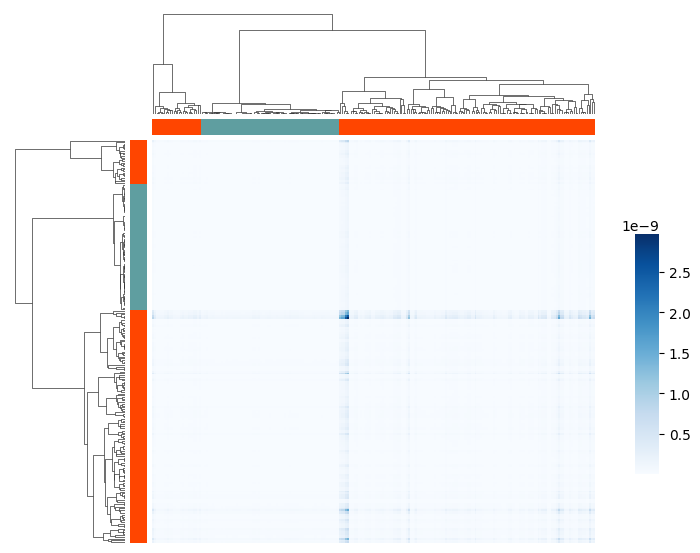

In [11]:
plot_heatmap(kernel, col_colors=label_colors, row_colors=label_colors,
             linkage_matrix_col=linkage_matrix, linkage_matrix_row=linkage_matrix)

In [12]:
theta_t = (AD/DP).fillna(0)
theta_t[theta_t==0] = 1e-15
theta_t[theta_t==1] = 1. - 1e-15
gamma_t = mu_t = logit(theta_t)

In [13]:
data_true = pd.concat([array_to_df(theta_t, "VAF", cell_ids), \
                       array_to_df(AD, "AD", cell_ids)["AD"], \
                       array_to_df(DP, "DP", cell_ids)["DP"], \
                       array_to_df(gamma_t, "gamma", cell_ids)["gamma"]], \
                       axis=1, join="inner")
data_true["clone_ids"] = [str(assignments[i]) for i in data_true["cell_ids"]]
data_true.head()

,mutation_ids,cell_ids,VAF,AD,DP,gamma,clone_ids
0,chr3:93309671:G:A,22187,1.000000e-15,0,0,-34.538776,B
1,chr8:55948271:G:A,22187,1.000000e-15,0,0,-34.538776,B
2,chr17:9399530:C:A,22187,1.000000e-15,0,0,-34.538776,B
3,chr3:133575683:AT:A,22187,1.000000e-15,0,0,-34.538776,B
4,chr4:87671170:C:G,22187,1.000000e-15,0,0,-34.538776,B


/orfeo/cephfs/scratch/cdslab/ebusca00/envs/virtualenv/jupyter/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


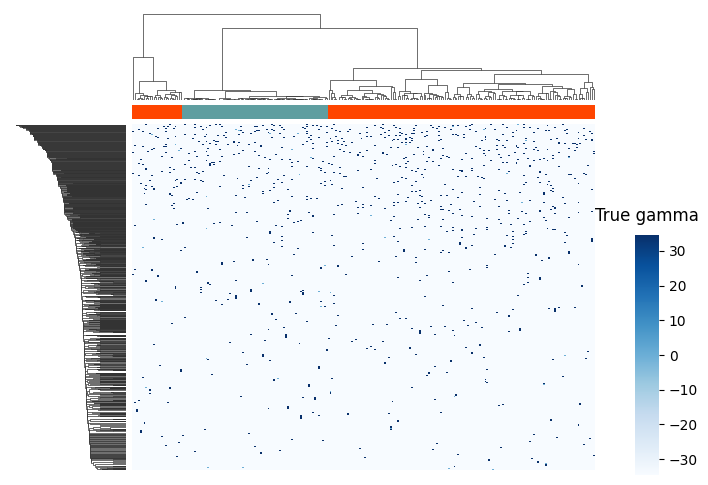

In [14]:
plot_heatmap(gamma_t, col_colors=label_colors, linkage_matrix_col=linkage_matrix,
            legend_title="True gamma")

/orfeo/cephfs/scratch/cdslab/ebusca00/envs/virtualenv/jupyter/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


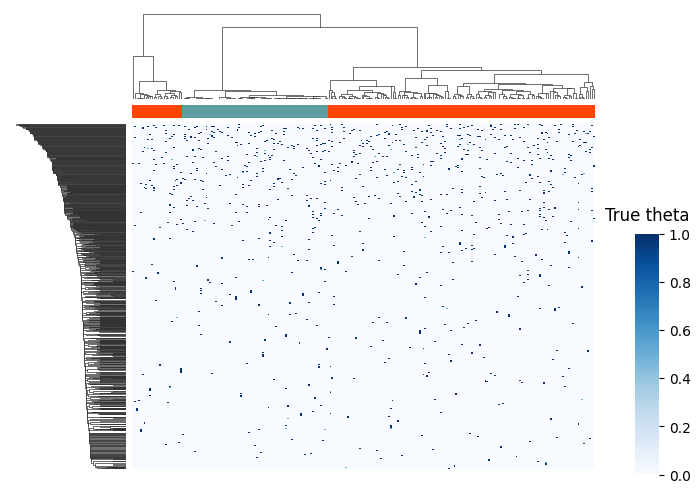

In [15]:
plot_heatmap(theta_t, col_colors=label_colors, linkage_matrix_col=linkage_matrix,
             legend_title="True theta")

/orfeo/cephfs/scratch/cdslab/ebusca00/envs/virtualenv/jupyter/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


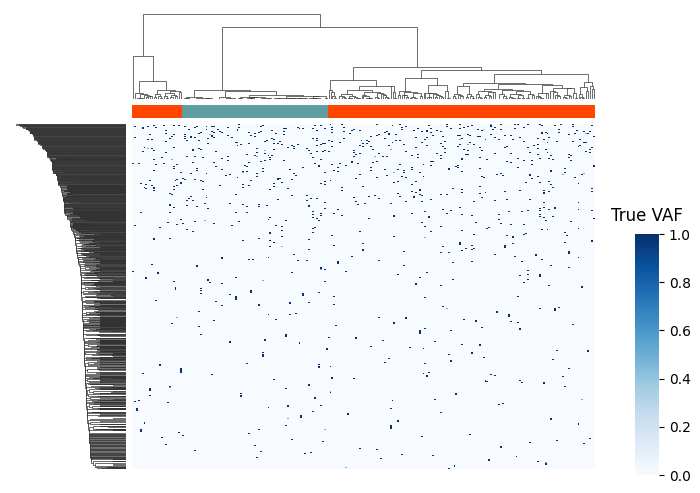

In [16]:
plot_heatmap((AD/DP).fillna(0), col_colors=label_colors, linkage_matrix_col=linkage_matrix,
             legend_title="True VAF")

# Run the model

In [17]:
import torch
import time
import torch.nn as nn
import torch.optim as optim
import numpy as np

from torch.autograd.functional import hessian
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
device = torch.device("cuda")

In [19]:
# convert to tensor the data
Y = torch.tensor(AD.values).to(device=device)
D = torch.tensor(DP.values).to(device=device)
# Z = torch.tensor(clone_ids, dtype=torch.int, device=device)

V, N = Y.shape  # #mutations x #cells
K = len(set(assignments.values()))  # #clones

learning_rate = 0.005

assert Y.shape[1] == D.shape[1]
# assert Y.shape[1] == Z.shape[0]
print(f"{V} SNPs, {N} cells and {K} clones\n")

print(f"Devices\nY = {Y.device}\nD = {D.device}")

1000 SNPs, 239 cells and 2 clones

Devices
Y = cuda:0
D = cuda:0


In [20]:
# Initialize mu
mu_init = logit_clipped((Y/D).nan_to_num(0))  # initialize mu as a sampling from a beta(1,1)
mu = mu_init.detach().clone().requires_grad_(True)

# Initialize gamma
# gamma_hat_init = logit_clipped(Y/D) + torch.normal(mean=torch.zeros_like(Y, dtype=torch.float32), std=torch.ones_like(Y, dtype=torch.float32))
gamma_hat_init = torch.randn_like(mu)
gamma_hat = mu_init.detach().clone().requires_grad_(False)

# Initialize the covariance matrix
Sigma = torch.tensor(kernel, dtype=torch.float32, device=device) + 1e-6*torch.eye(N, device=device)
Sigma_inv = torch.linalg.inv(Sigma)  # inverese of Sigma -> N x N
log_det_Sigma = torch.logdet(Sigma)  # log of determinant of Sigma

# Check the device of all parameters
print(f"Devices\nmu = {mu.device}\nSigma = {Sigma.device}\nSigma_inv = {Sigma_inv.device}\nlog_det_Sigma = {log_det_Sigma.device}\ngamma_hat = {gamma_hat.device}")

Devices
mu = cuda:0
Sigma = cuda:0
Sigma_inv = cuda:0
log_det_Sigma = cuda:0
gamma_hat = cuda:0


In [21]:
# Optimizer
optimizer = optim.Adam([mu], lr=learning_rate)

# Store initial time and lists
start_time = time.time()
losses, gradients = [], []

# Start the inference
pbar = tqdm(range(40))
for _ in pbar:

    optimizer.zero_grad()  # reset the gradient
    total_laplace = 0.0
    for v in range(V):
        # compute log p(y_v | d_v, mu_v, Sigma) with laplace approx
        y_v = Y[v, :]
        d_v = D[v, :]
        laplace_term, gamma_hat_v = compute_laplace_term(y_v, d_v, mu[v,:], Sigma_inv, gamma_hat[v,:])
        
        total_laplace += laplace_term
        gamma_hat[v,:] = gamma_hat_v

    loss = -total_laplace
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    gradients.append(mu.grad.norm().item())

    pbar.set_description(f"Loss = {loss.item()}")

# Store final time
end_time = time.time()

Loss = 3223948.25: 100%|██████████| 40/40 [07:22<00:00, 11.06s/it]


# Evaluation

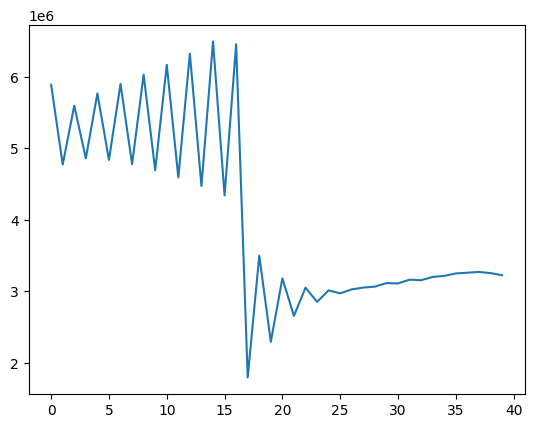

In [22]:
plt.plot(losses)

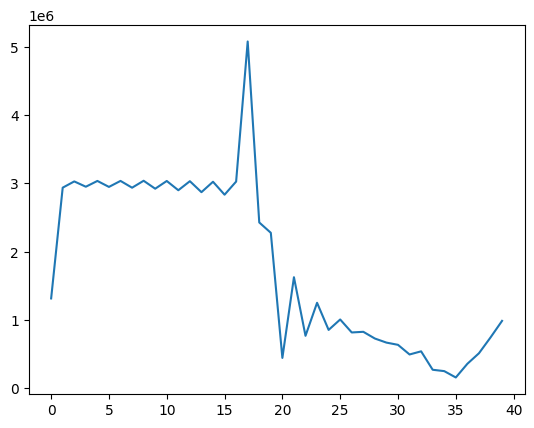

In [23]:
plt.plot(gradients)

/orfeo/cephfs/scratch/cdslab/ebusca00/envs/virtualenv/jupyter/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/orfeo/cephfs/scratch/cdslab/ebusca00/envs/virtualenv/jupyter/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


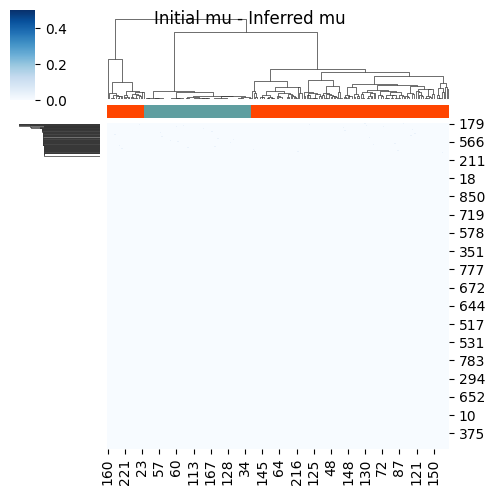

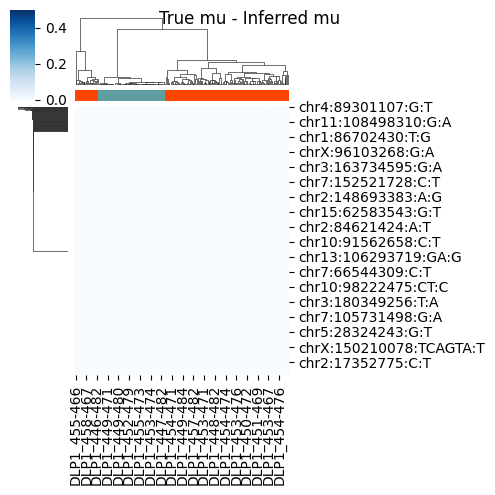

In [24]:
mu_np = mu.cpu().detach().numpy()

pl1 = sns.clustermap(np.abs(expit(mu_init.cpu().numpy()) - expit(mu_np)),
                     col_colors=[color_map[i] for i in clone_ids],
                     col_linkage=linkage_matrix,
                     row_cluster=True,
                     cmap="Blues",
                     vmin=0., vmax=0.5,
                     figsize=(5, 5))
pl1 = pl1.fig.suptitle("Initial mu - Inferred mu")

pl3 = sns.clustermap(np.abs(expit(gamma_t) - expit(mu_np)),
                     col_colors=[color_map[i] for i in clone_ids],
                     col_linkage=linkage_matrix,
                     row_cluster=True,
                     cmap="Blues",
                     vmin=0., vmax=0.5,
                     figsize=(5, 5))
pl3 = pl3.fig.suptitle("True mu - Inferred mu")

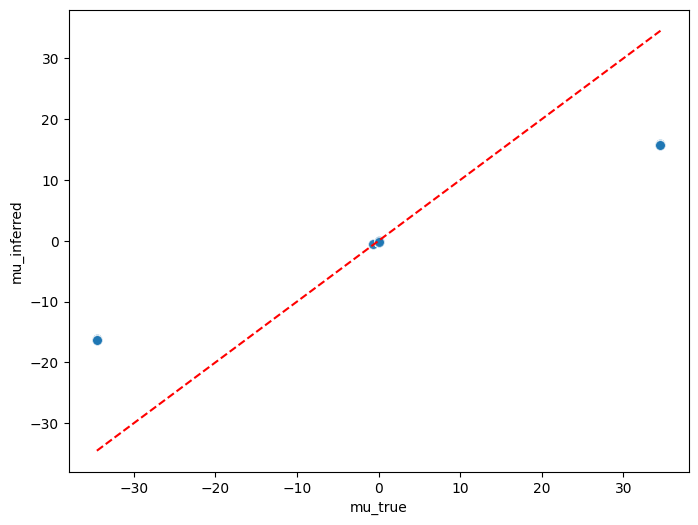

In [25]:
df = pd.DataFrame({"mu_true": torch.tensor(gamma_t.values).flatten(), "mu_inferred": mu_np.flatten()})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="mu_true", y="mu_inferred", alpha=0.6, s=50, edgecolor="w")
min_val = min(np.min(df.mu_true), np.min(df.mu_inferred))
max_val = max(np.max(df.mu_true), np.max(df.mu_inferred))
plt.plot([min_val, max_val], [min_val, max_val], "r--")

/orfeo/cephfs/scratch/cdslab/ebusca00/envs/virtualenv/jupyter/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/orfeo/cephfs/scratch/cdslab/ebusca00/envs/virtualenv/jupyter/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/orfeo/cephfs/scratch/cdslab/ebusca00/envs/virtualenv/jupyter/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


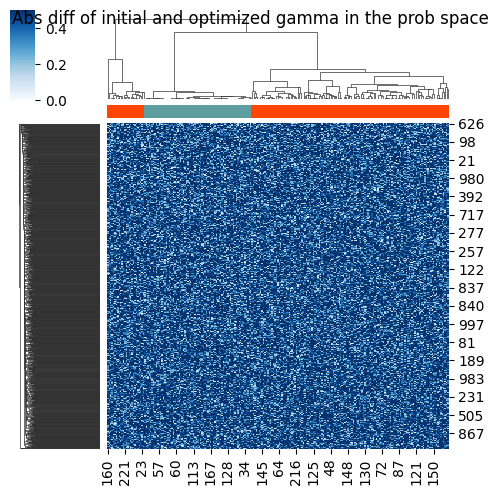

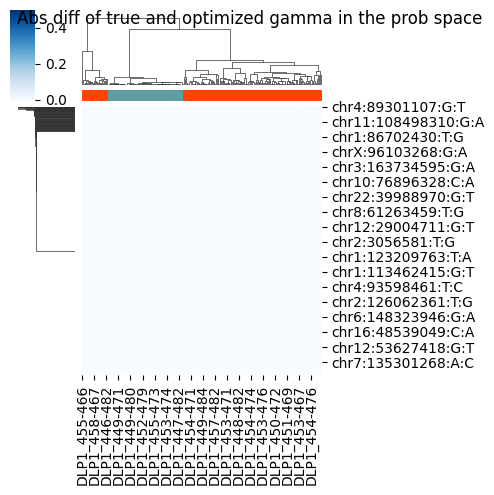

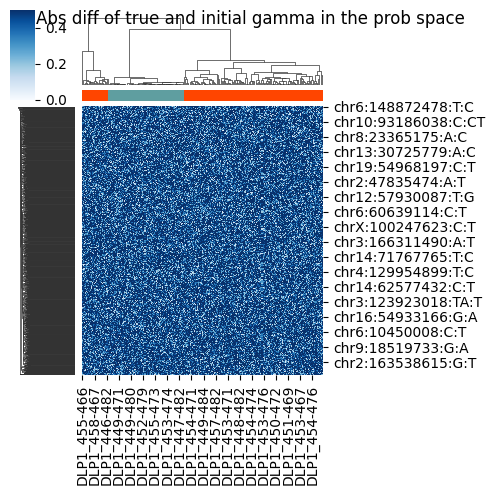

In [26]:
pl1 = sns.clustermap(np.abs(expit(gamma_hat_init.cpu().numpy()) - expit(gamma_hat.cpu().numpy())),
                     col_colors=[color_map[i] for i in clone_ids],
                     col_linkage=linkage_matrix,
                     row_cluster=True,
                     cmap="Blues",
                     vmin=0, vmax=0.5,
                     figsize=(5, 5))
pl1 = pl1.fig.suptitle("Abs diff of initial and optimized gamma in the prob space")

pl2 = sns.clustermap(np.abs(expit(gamma_t) - expit(gamma_hat.cpu().numpy())),
                     col_colors=[color_map[i] for i in clone_ids],
                     col_linkage=linkage_matrix,
                     row_cluster=True,
                     cmap="Blues",
                     vmin=0, vmax=0.5,
                     figsize=(5, 5))
pl2 = pl2.fig.suptitle("Abs diff of true and optimized gamma in the prob space")

pl3 = sns.clustermap(np.abs(expit(gamma_t) - expit(gamma_hat_init.cpu().numpy())),
                     col_colors=[color_map[i] for i in clone_ids],
                     col_linkage=linkage_matrix,
                     row_cluster=True,
                     cmap="Blues",
                     vmin=0, vmax=0.5,
                     figsize=(5, 5))
pl3 = pl3.fig.suptitle("Abs diff of true and initial gamma in the prob space")
# pl2 = sns.clustermap(gamma_true, col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 5))
# pl2 = pl2.fig.suptitle("True gamma")

/orfeo/cephfs/scratch/cdslab/ebusca00/envs/virtualenv/jupyter/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/orfeo/cephfs/scratch/cdslab/ebusca00/envs/virtualenv/jupyter/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/orfeo/cephfs/scratch/cdslab/ebusca00/envs/virtualenv/jupyter/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


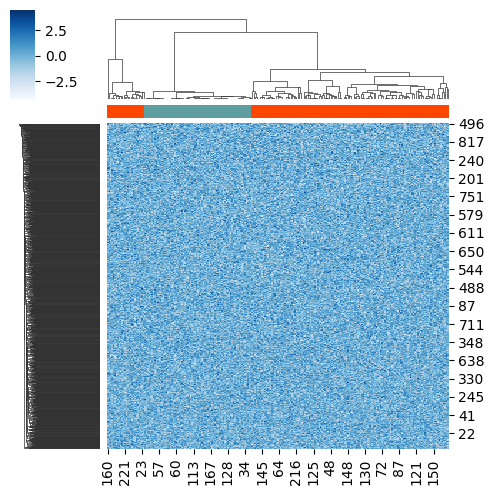

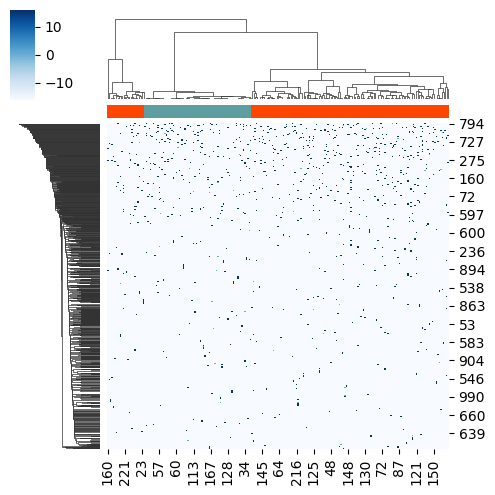

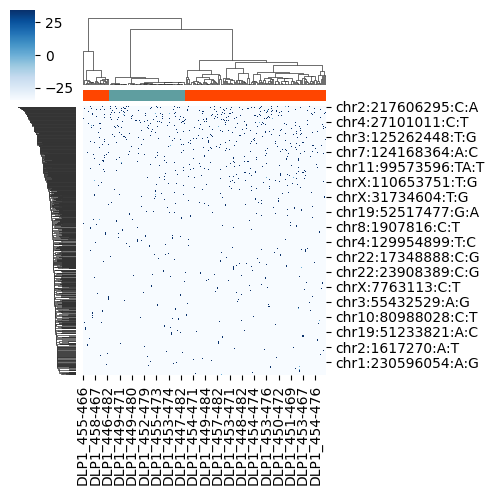

In [27]:
sns.clustermap(gamma_hat_init.cpu().numpy(), col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 5))
sns.clustermap(gamma_hat.cpu().numpy(), col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 5))
sns.clustermap(gamma_t, col_colors=[color_map[i] for i in clone_ids], col_linkage=linkage_matrix, row_cluster=True, cmap="Blues", figsize=(5, 5))